# Individual Homework 05 – Applied: ML Security and Abuse Pathways


## 0. Setup, Data Loading, and Clean Baseline

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.base import clone

RANDOM_STATE = 42
THR = 0.50
np.random.seed(RANDOM_STATE)

# Load COMPAS dataset directly from ProPublica GitHub.
URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_raw = pd.read_csv(URL)

# Lecture-style COMPAS filtering.
df = df_raw.copy()
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

FEATURES = [
    "age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
    "c_charge_degree", "sex"
]
TARGET = "two_year_recid"

# Keep race for fairness auditing, but do not use race as a model feature.
df_m = df[FEATURES + [TARGET, "race"]].dropna().copy()
df_m = pd.get_dummies(df_m, columns=["c_charge_degree", "sex"], drop_first=True)

X = df_m.drop(columns=[TARGET, "race"]).astype(float)
y = df_m[TARGET].astype(int).values
race = df_m["race"].values

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
Xs_tr = scaler.fit_transform(X_tr)
Xs_te = scaler.transform(X_te)
feature_names = list(X.columns)

lr = LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0, random_state=RANDOM_STATE)
gbt = GradientBoostingClassifier(n_estimators=250, max_depth=4, random_state=RANDOM_STATE)

lr.fit(Xs_tr, y_tr)
gbt.fit(Xs_tr, y_tr)

models = {"LR": lr, "GBT": gbt}

print(f"Raw dataset: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"Filtered analytic dataset: {len(df_m):,} rows")
print(f"Features used: {feature_names}")
print(f"Class balance: {y.mean():.3f} recidivism rate")
for name, model in models.items():
    train_auc = roc_auc_score(y_tr, model.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, model.predict_proba(Xs_te)[:, 1])
    print(f"{name}: train AUC={train_auc:.3f}, test AUC={test_auc:.3f}, gap={train_auc-test_auc:+.3f}")

Raw dataset: 7,214 rows, 53 columns
Filtered analytic dataset: 6,172 rows
Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 0.455 recidivism rate
LR: train AUC=0.727, test AUC=0.735, gap=-0.008
GBT: train AUC=0.806, test AUC=0.714, gap=+0.092


In [ ]:
# Fairness helpers

def fpr_by_race(y_true, y_pred, groups):
    """False positive rate by race: P(pred=1 | y=0, race)."""
    rows = []
    for g in sorted(pd.Series(groups).dropna().unique()):
        mask = (groups == g) & (y_true == 0)
        if mask.sum() == 0:
            fpr = np.nan
        else:
            fpr = y_pred[mask].mean()
        rows.append({"race": g, "n_true_negative": int(mask.sum()), "FPR": fpr})
    return pd.DataFrame(rows)

def fpr_pair_and_air(y_true, y_pred, groups):
    """AIR defined as FPR_African-American / FPR_Caucasian for the harmful high-risk label."""
    fprs = fpr_by_race(y_true, y_pred, groups)
    aa = fprs.loc[fprs["race"] == "African-American", "FPR"]
    ca = fprs.loc[fprs["race"] == "Caucasian", "FPR"]
    fpr_aa = float(aa.iloc[0]) if len(aa) else np.nan
    fpr_ca = float(ca.iloc[0]) if len(ca) else np.nan
    air = fpr_aa / fpr_ca if fpr_ca and not np.isnan(fpr_ca) else np.nan
    return fpr_aa, fpr_ca, air

def clean_baseline_table():
    rows = []
    for name, model in models.items():
        probs = model.predict_proba(Xs_te)[:, 1]
        preds = (probs >= THR).astype(int)
        fpr_aa, fpr_ca, air_val = fpr_pair_and_air(y_te, preds, r_te)
        rows.append({
            "model": name,
            "test_auc": roc_auc_score(y_te, probs),
            "accuracy": accuracy_score(y_te, preds),
            "FPR_African-American": fpr_aa,
            "FPR_Caucasian": fpr_ca,
            "AIR_AA_over_CA": air_val
        })
    return pd.DataFrame(rows)

baseline_table = clean_baseline_table()
display(baseline_table.round(4))

BASELINE_AUC_LR = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
BASELINE_AIR_LR = baseline_table.loc[baseline_table["model"] == "LR", "AIR_AA_over_CA"].iloc[0]

,model,test_auc,accuracy,FPR_African-American,FPR_Caucasian,AIR_AA_over_CA
0,LR,0.7345,0.6825,0.2809,0.1432,1.9614
1,GBT,0.7137,0.6647,0.3191,0.1852,1.7231


## 1. PGD Evasion Audit


In [ ]:
EPSILONS = [0.25, 0.5, 1.0, 2.0]

def lr_score_gradient(model, X_scaled):
    """Gradient of high-risk probability for logistic regression: p(1-p)w."""
    p = model.predict_proba(X_scaled)[:, 1]
    w = model.coef_[0]
    return (p * (1 - p))[:, None] * w[None, :]

def finite_difference_score_gradient(model, X_scaled, epsilon, h=None):
    """Central finite-difference gradient of predicted high-risk probability."""
    if h is None:
        # Larger h is necessary for tree models because small perturbations often do not cross split thresholds.
        h = max(0.05, epsilon / 4)
    grad = np.zeros_like(X_scaled, dtype=float)
    for j in range(X_scaled.shape[1]):
        X_plus = X_scaled.copy()
        X_minus = X_scaled.copy()
        X_plus[:, j] += h
        X_minus[:, j] -= h
        p_plus = model.predict_proba(X_plus)[:, 1]
        p_minus = model.predict_proba(X_minus)[:, 1]
        grad[:, j] = (p_plus - p_minus) / (2 * h)
    return grad

def random_restart_improve(model, X0, X_adv, epsilon, n_random=25, seed=RANDOM_STATE):
    """Additional score-based restarts so the non-differentiable GBT attack actually explores the epsilon ball."""
    rng = np.random.default_rng(seed)
    best = X_adv.copy()
    best_score = model.predict_proba(best)[:, 1]
    for _ in range(n_random):
        cand = X0 + rng.uniform(-epsilon, epsilon, size=X0.shape)
        score = model.predict_proba(cand)[:, 1]
        take = score > best_score
        best[take] = cand[take]
        best_score[take] = score[take]
    return best

def pgd_evasion(model, X_scaled, epsilon, model_name, alpha=None, n_iter=30):
    """Projected attack that pushes predicted high-risk probability upward under an L-infinity budget."""
    if alpha is None:
        alpha = epsilon / 8
    X0 = X_scaled.copy()
    X_adv = X_scaled.copy()

    for _ in range(n_iter):
        if model_name == "LR":
            grad = lr_score_gradient(model, X_adv)
        else:
            grad = finite_difference_score_gradient(model, X_adv, epsilon=epsilon)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X0 - epsilon, X0 + epsilon)

    if model_name == "GBT":
        X_adv = random_restart_improve(model, X0, X_adv, epsilon, n_random=30)

    return X_adv

pgd_rows = []
for name, model in models.items():
    for eps in EPSILONS:
        X_adv = pgd_evasion(model, Xs_te, epsilon=eps, model_name=name, n_iter=30)
        probs_adv = model.predict_proba(X_adv)[:, 1]
        preds_adv = (probs_adv >= THR).astype(int)
        fpr_aa, fpr_ca, air_val = fpr_pair_and_air(y_te, preds_adv, r_te)

        pgd_rows.append({
            "model": name,
            "epsilon": eps,
            "FPR_African-American": fpr_aa,
            "FPR_Caucasian": fpr_ca,
            "AIR_AA_over_CA": air_val,
            "mean_score": probs_adv.mean(),
            "positive_rate": preds_adv.mean()
        })

pgd_table = pd.DataFrame(pgd_rows)
display(pgd_table.round(4))

pgd_crossing = []
for name, sub in pgd_table.groupby("model"):
    below = sub[sub["AIR_AA_over_CA"] < 0.80]
    eps_below = None if below.empty else float(below.sort_values("epsilon").iloc[0]["epsilon"])
    outside = sub[(sub["AIR_AA_over_CA"] < 0.80) | (sub["AIR_AA_over_CA"] > 1.25)]
    eps_outside = None if outside.empty else float(outside.sort_values("epsilon").iloc[0]["epsilon"])
    pgd_crossing.append({
        "model": name,
        "epsilon_AIR_below_0.80": eps_below,
        "epsilon_AIR_outside_[0.80,1.25]": eps_outside
    })

pgd_crossing_table = pd.DataFrame(pgd_crossing)
display(pgd_crossing_table)

,model,epsilon,FPR_African-American,FPR_Caucasian,AIR_AA_over_CA,mean_score,positive_rate
0,LR,0.25,0.5685,0.3704,1.5351,0.5417,0.5999
1,LR,0.50,0.7910,0.5605,1.4113,0.6289,0.7748
2,LR,1.00,0.9775,0.8840,1.1059,0.7794,0.9563
3,LR,2.00,1.0000,1.0000,1.0000,0.9433,1.0000
4,GBT,0.25,0.6764,0.4840,1.3977,0.6481,0.6820
5,GBT,0.50,0.8112,0.6272,1.2935,0.7406,0.7900
6,GBT,1.00,0.9798,0.9383,1.0442,0.8782,0.9681
7,GBT,2.00,1.0000,1.0000,1.0000,0.9701,0.9995


,model,epsilon_AIR_below_0.80,"epsilon_AIR_outside_[0.80,1.25]"
0,GBT,None,0.25
1,LR,None,0.25


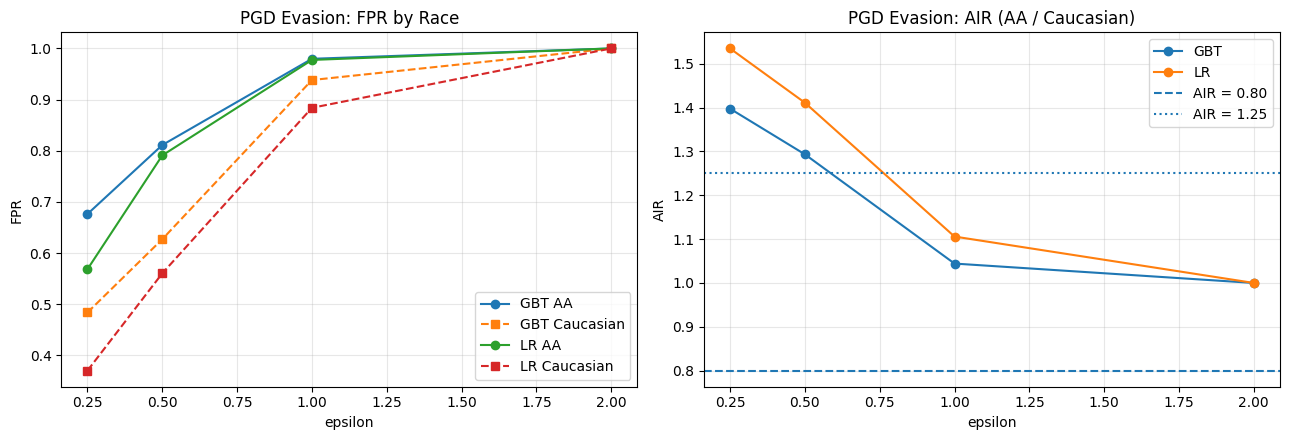

PGD interpretation:
GBT crosses below AIR=0.80 at ε=None and is outside [0.80,1.25] at ε=0.25. LR crosses below AIR=0.80 at ε=None and is outside [0.80,1.25] at ε=0.25.
The two models should not be treated as equally vulnerable. Compare the slope of the FPR curves, the movement in AIR, and the epsilon at which AIR becomes unacceptable. In high-stakes deployment, model selection should consider adversarial fairness stability, not only clean AUC. A model with slightly lower clean AUC may be preferable if it keeps FPR and AIR more stable under evasion.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, sub in pgd_table.groupby("model"):
    axes[0].plot(sub["epsilon"], sub["FPR_African-American"], marker="o", label=f"{name} AA")
    axes[0].plot(sub["epsilon"], sub["FPR_Caucasian"], marker="s", linestyle="--", label=f"{name} Caucasian")
    axes[1].plot(sub["epsilon"], sub["AIR_AA_over_CA"], marker="o", label=name)

axes[0].set_title("PGD Evasion: FPR by Race")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("FPR")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.80, linestyle="--", label="AIR = 0.80")
axes[1].axhline(1.25, linestyle=":", label="AIR = 1.25")
axes[1].set_title("PGD Evasion: AIR (AA / Caucasian)")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("AIR")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# One-paragraph answer generated from the output.
pgd_summary = []
for _, row in pgd_crossing_table.iterrows():
    pgd_summary.append(
        f"{row['model']} crosses below AIR=0.80 at ε={row['epsilon_AIR_below_0.80']} "
        f"and is outside [0.80,1.25] at ε={row['epsilon_AIR_outside_[0.80,1.25]']}."
    )

print("PGD interpretation:")
print(" ".join(pgd_summary))
print(
    "The two models should not be treated as equally vulnerable. Compare the slope of the FPR curves, "
    "the movement in AIR, and the epsilon at which AIR becomes unacceptable. In high-stakes deployment, "
    "model selection should consider adversarial fairness stability, not only clean AUC. A model with slightly "
    "lower clean AUC may be preferable if it keeps FPR and AIR more stable under evasion."
)

## 2. Poisoning Loop with Fairness Monitoring

The lecture poisoning loop flips labels for targeted defendants. This version runs **both target-race variants**: African-American and Caucasian. The attack flips eligible target-race training labels from `1 → 0`, which simulates an adversary trying to under-score high-risk members of the target group while leaving feature distributions unchanged.

In [ ]:
POISON_RATES = [0.00, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
TARGET_RACES = ["African-American", "Caucasian"]

def poison_label_flip(y_train, race_train, target_race, poison_rate, seed=RANDOM_STATE):
    """Flip a fraction of target-race positive labels from 1 to 0."""
    rng = np.random.default_rng(seed)
    y_poison = y_train.copy()
    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(np.floor(len(candidates) * poison_rate))
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poison[flip_idx] = 0
    return y_poison, n_flip

def psi_numeric(expected, actual, bins=10, eps=1e-6):
    """Population Stability Index for one numeric feature."""
    expected = pd.Series(expected).dropna().astype(float).values
    actual = pd.Series(actual).dropna().astype(float).values
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    cuts = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(cuts) <= 2:
        lo = min(expected.min(), actual.min())
        hi = max(expected.max(), actual.max())
        if lo == hi:
            return 0.0
        cuts = np.linspace(lo, hi, bins + 1)
    cuts[0], cuts[-1] = -np.inf, np.inf
    e_counts = np.histogram(expected, bins=cuts)[0]
    a_counts = np.histogram(actual, bins=cuts)[0]
    e_pct = np.clip(e_counts / max(e_counts.sum(), 1), eps, None)
    a_pct = np.clip(a_counts / max(a_counts.sum(), 1), eps, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

poison_rows = []
psi_rows = []

for target_race in TARGET_RACES:
    for rate in POISON_RATES:
        y_poison, n_flipped = poison_label_flip(y_tr, r_tr, target_race, rate)

        model_p = LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0, random_state=RANDOM_STATE)
        model_p.fit(Xs_tr, y_poison)

        probs = model_p.predict_proba(Xs_te)[:, 1]
        preds = (probs >= THR).astype(int)
        fpr_aa, fpr_ca, air_val = fpr_pair_and_air(y_te, preds, r_te)

        poison_rows.append({
            "target_race": target_race,
            "poison_rate": rate,
            "n_flipped": n_flipped,
            "AUC": roc_auc_score(y_te, probs),
            "AUC_drop_pp": 100 * (BASELINE_AUC_LR - roc_auc_score(y_te, probs)),
            "FPR_African-American": fpr_aa,
            "FPR_Caucasian": fpr_ca,
            "AIR_AA_over_CA": air_val
        })

        # Feature PSI evidence. Because this poisoning attack changes labels only, the training features are identical.
        max_psi = max(psi_numeric(X_tr[col], X_tr[col]) for col in X_tr.columns)
        psi_rows.append({"target_race": target_race, "poison_rate": rate, "max_feature_PSI": max_psi})

poison_table = pd.DataFrame(poison_rows)
psi_poison_table = pd.DataFrame(psi_rows)

display(poison_table.round(4))

stealth = poison_table[
    (poison_table["poison_rate"] > 0) &
    (poison_table["AUC_drop_pp"] <= 2.0) &
    ((poison_table["AIR_AA_over_CA"] < 0.80) | (poison_table["AIR_AA_over_CA"] > 1.25))
].copy()

print("Stealth-zone rows: AUC drop <= 2 pp and AIR outside [0.80, 1.25]")
display(stealth.round(4))

stealth_ranges = []
for target, sub in stealth.groupby("target_race"):
    stealth_ranges.append({
        "target_race": target,
        "stealth_min_poison_rate": sub["poison_rate"].min(),
        "stealth_max_poison_rate": sub["poison_rate"].max(),
        "n_stealth_grid_points": len(sub)
    })
stealth_range_table = pd.DataFrame(stealth_ranges)
display(stealth_range_table)

print("PSI evidence for feature-level drift monitor:")
psi_summary = psi_poison_table.groupby("target_race")["max_feature_PSI"].max().reset_index()
display(psi_summary.round(6))

,target_race,poison_rate,n_flipped,AUC,AUC_drop_pp,FPR_African-American,FPR_Caucasian,AIR_AA_over_CA
0,African-American,0.00,0,0.7345,0.0000,0.2809,0.1432,1.9614
1,African-American,0.01,11,0.7341,0.0409,0.2787,0.1407,1.9799
2,African-American,0.02,23,0.7342,0.0384,0.2697,0.1333,2.0225
3,African-American,0.05,57,0.7350,-0.0455,0.2315,0.1235,1.8748
4,African-American,0.08,92,0.7338,0.0759,0.2157,0.1111,1.9416
5,African-American,0.10,115,0.7330,0.1579,0.2000,0.1037,1.9286
6,African-American,0.15,172,0.7327,0.1801,0.1528,0.0716,2.1341
7,African-American,0.20,230,0.7285,0.6046,0.1281,0.0543,2.3580
8,African-American,0.25,287,0.7290,0.5523,0.1124,0.0469,2.3950
9,African-American,0.30,345,0.7307,0.3859,0.0989,0.0346,2.8604


Stealth-zone rows: AUC drop <= 2 pp and AIR outside [0.80, 1.25]


,target_race,poison_rate,n_flipped,AUC,AUC_drop_pp,FPR_African-American,FPR_Caucasian,AIR_AA_over_CA
1,African-American,0.01,11,0.7341,0.0409,0.2787,0.1407,1.9799
2,African-American,0.02,23,0.7342,0.0384,0.2697,0.1333,2.0225
3,African-American,0.05,57,0.7350,-0.0455,0.2315,0.1235,1.8748
4,African-American,0.08,92,0.7338,0.0759,0.2157,0.1111,1.9416
5,African-American,0.10,115,0.7330,0.1579,0.2000,0.1037,1.9286
6,African-American,0.15,172,0.7327,0.1801,0.1528,0.0716,2.1341
7,African-American,0.20,230,0.7285,0.6046,0.1281,0.0543,2.3580
8,African-American,0.25,287,0.7290,0.5523,0.1124,0.0469,2.3950
9,African-American,0.30,345,0.7307,0.3859,0.0989,0.0346,2.8604
11,Caucasian,0.01,5,0.7340,0.0537,0.2787,0.1432,1.9458


,target_race,stealth_min_poison_rate,stealth_max_poison_rate,n_stealth_grid_points
0,African-American,0.01,0.3,9
1,Caucasian,0.01,0.3,9


PSI evidence for feature-level drift monitor:


,target_race,max_feature_PSI
0,African-American,0.0
1,Caucasian,0.0


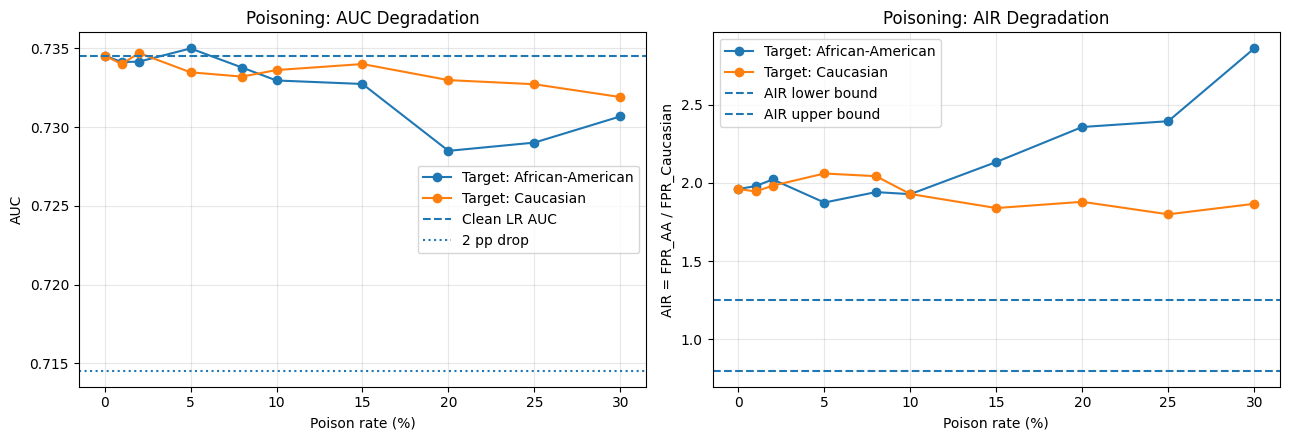

Poisoning interpretation:
Target African-American: stealth zone from 1.0% to 30.0% on the tested grid.
Target Caucasian: stealth zone from 1.0% to 30.0% on the tested grid.
The PSI feature monitor would not detect this attack because the maximum feature PSI is 0.0: the attack changes training labels, not feature values. Therefore, feature-only drift monitoring is insufficient; monitoring must include label provenance, subgroup fairness metrics, and model-output behavior.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for target_race, sub in poison_table.groupby("target_race"):
    x = sub["poison_rate"] * 100
    axes[0].plot(x, sub["AUC"], marker="o", label=f"Target: {target_race}")
    axes[1].plot(x, sub["AIR_AA_over_CA"], marker="o", label=f"Target: {target_race}")

axes[0].axhline(BASELINE_AUC_LR, linestyle="--", label="Clean LR AUC")
axes[0].axhline(BASELINE_AUC_LR - 0.02, linestyle=":", label="2 pp drop")
axes[0].set_title("Poisoning: AUC Degradation")
axes[0].set_xlabel("Poison rate (%)")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.80, linestyle="--", label="AIR lower bound")
axes[1].axhline(1.25, linestyle="--", label="AIR upper bound")
axes[1].set_title("Poisoning: AIR Degradation")
axes[1].set_xlabel("Poison rate (%)")
axes[1].set_ylabel("AIR = FPR_AA / FPR_Caucasian")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Poisoning interpretation:")
if len(stealth_range_table):
    for _, row in stealth_range_table.iterrows():
        print(
            f"Target {row['target_race']}: stealth zone from "
            f"{100*row['stealth_min_poison_rate']:.1f}% to {100*row['stealth_max_poison_rate']:.1f}% "
            f"on the tested grid."
        )
else:
    print("No stealth-zone row was found on the tested poison-rate grid.")

print(
    "The PSI feature monitor would not detect this attack because the maximum feature PSI is 0.0: "
    "the attack changes training labels, not feature values. Therefore, feature-only drift monitoring is insufficient; "
    "monitoring must include label provenance, subgroup fairness metrics, and model-output behavior."
)

## 3. Membership Inference Depth

This section computes the shadow-model membership inference AUC for both LR and GBT. It then plots confidence-gap histograms side by side and checks whether the generalization gap descriptively tracks MI AUC. Because there are only two base models, this is **not** a valid statistical test; it is only an audit comparison.

In [ ]:
def shadow_mi_auc(target_model, target_name, model_factory, n_shadow=8, random_state=RANDOM_STATE):
    """Shadow-model membership inference using max confidence as the attack feature."""
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=random_state)
    member_conf, nonmember_conf = [], []

    for idx_in, idx_out in sss.split(Xs_tr, y_tr):
        shadow = model_factory()
        shadow.fit(Xs_tr[idx_in], y_tr[idx_in])
        member_conf.append(shadow.predict_proba(Xs_tr[idx_in]).max(axis=1))
        nonmember_conf.append(shadow.predict_proba(Xs_tr[idx_out]).max(axis=1))

    attack_X = np.concatenate(member_conf + nonmember_conf).reshape(-1, 1)
    attack_y = np.concatenate([
        np.ones(sum(len(x) for x in member_conf)),
        np.zeros(sum(len(x) for x in nonmember_conf))
    ])

    attack_clf = LogisticRegression(max_iter=1000, random_state=random_state)
    attack_clf.fit(attack_X, attack_y)

    target_train_conf = target_model.predict_proba(Xs_tr).max(axis=1)
    target_test_conf = target_model.predict_proba(Xs_te).max(axis=1)

    target_attack_X = np.concatenate([target_train_conf, target_test_conf]).reshape(-1, 1)
    target_attack_y = np.concatenate([np.ones(len(target_train_conf)), np.zeros(len(target_test_conf))])
    mi_scores = attack_clf.predict_proba(target_attack_X)[:, 1]
    mi_auc_val = roc_auc_score(target_attack_y, mi_scores)

    train_auc = roc_auc_score(y_tr, target_model.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, target_model.predict_proba(Xs_te)[:, 1])

    return {
        "model": target_name,
        "MI_AUC": mi_auc_val,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "generalization_gap": train_auc - test_auc,
        "train_conf": target_train_conf,
        "test_conf": target_test_conf,
        "mi_scores": mi_scores,
        "mi_labels": target_attack_y
    }

mi_lr = shadow_mi_auc(
    lr, "LR",
    lambda: LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0, random_state=RANDOM_STATE)
)
mi_gbt = shadow_mi_auc(
    gbt, "GBT",
    lambda: GradientBoostingClassifier(n_estimators=250, max_depth=4, random_state=RANDOM_STATE)
)

mi_results = pd.DataFrame([
    {k: v for k, v in d.items() if k not in ["train_conf", "test_conf", "mi_scores", "mi_labels"]}
    for d in [mi_lr, mi_gbt]
])
display(mi_results.round(4))

# Descriptive only: with n=2, no formal statistical claim can be made.
if len(mi_results) == 2:
    corr = np.corrcoef(mi_results["generalization_gap"], mi_results["MI_AUC"])[0, 1]
else:
    corr = np.nan
print(f"Descriptive correlation between generalization gap and MI AUC across LR and GBT: {corr:.3f}")
print("Because there are only two models, this is not a statistically valid test of prediction.")

,model,MI_AUC,train_auc,test_auc,generalization_gap
0,LR,0.5017,0.7269,0.7345,-0.0077
1,GBT,0.5122,0.8055,0.7137,0.0919


Descriptive correlation between generalization gap and MI AUC across LR and GBT: 1.000
Because there are only two models, this is not a statistically valid test of prediction.


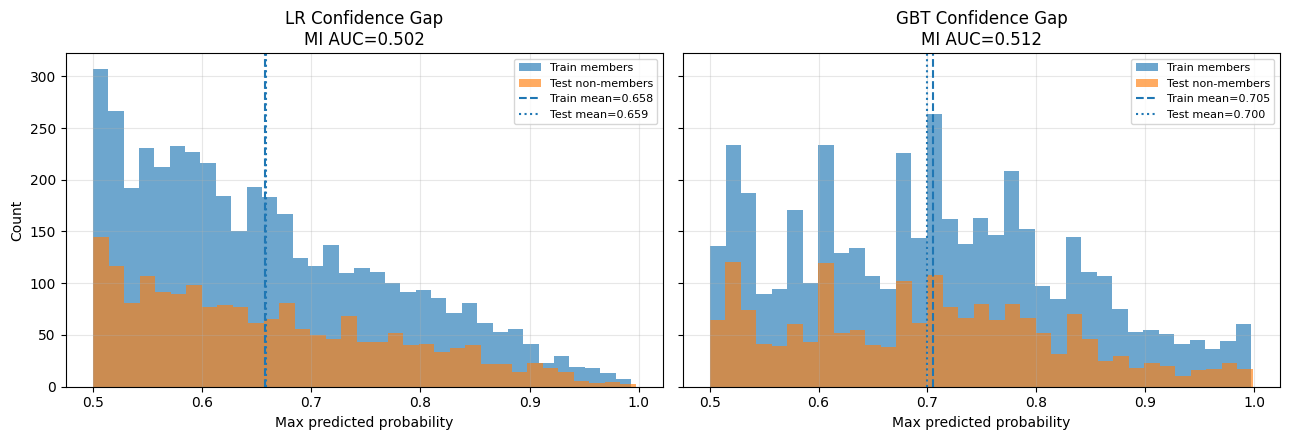

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, result in zip(axes, [mi_lr, mi_gbt]):
    ax.hist(result["train_conf"], bins=35, alpha=0.65, label="Train members")
    ax.hist(result["test_conf"], bins=35, alpha=0.65, label="Test non-members")
    ax.axvline(result["train_conf"].mean(), linestyle="--", label=f"Train mean={result['train_conf'].mean():.3f}")
    ax.axvline(result["test_conf"].mean(), linestyle=":", label=f"Test mean={result['test_conf'].mean():.3f}")
    ax.set_title(f"{result['model']} Confidence Gap\nMI AUC={result['MI_AUC']:.3f}")
    ax.set_xlabel("Max predicted probability")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

,C,MI_AUC,train_auc,test_auc,generalization_gap
0,0.01,0.5027,0.7258,0.7321,-0.0064
1,0.10,0.5017,0.7268,0.7342,-0.0074
2,1.00,0.5017,0.7269,0.7345,-0.0077
3,10.00,0.5017,0.7269,0.7346,-0.0077


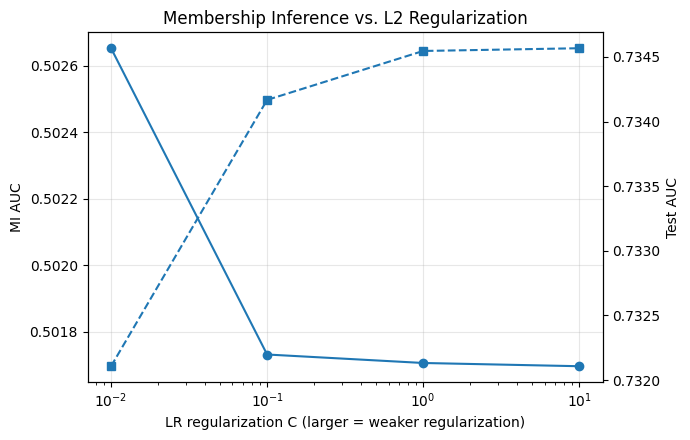

Membership inference interpretation:
MI AUC near 0.50 means the attack is close to random guessing. The regularization sweep shows the practical tradeoff: stronger L2 regularization can reduce confidence gaps and MI leakage, but too much regularization may also reduce predictive utility and may change subgroup fairness metrics.


In [ ]:
C_VALUES = [0.01, 0.1, 1.0, 10.0]
reg_rows = []

for C in C_VALUES:
    lr_c = LogisticRegression(max_iter=1000, solver="lbfgs", C=C, random_state=RANDOM_STATE)
    lr_c.fit(Xs_tr, y_tr)

    mi_c = shadow_mi_auc(
        lr_c, f"LR_C={C}",
        lambda C=C: LogisticRegression(max_iter=1000, solver="lbfgs", C=C, random_state=RANDOM_STATE),
        n_shadow=8
    )

    reg_rows.append({
        "C": C,
        "MI_AUC": mi_c["MI_AUC"],
        "train_auc": mi_c["train_auc"],
        "test_auc": mi_c["test_auc"],
        "generalization_gap": mi_c["generalization_gap"]
    })

reg_table = pd.DataFrame(reg_rows)
display(reg_table.round(4))

fig, ax1 = plt.subplots(figsize=(7, 4.5))

ax1.plot(reg_table["C"], reg_table["MI_AUC"], marker="o", label="MI AUC")
ax1.set_xscale("log")
ax1.set_xlabel("LR regularization C (larger = weaker regularization)")
ax1.set_ylabel("MI AUC")
ax1.set_title("Membership Inference vs. L2 Regularization")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(reg_table["C"], reg_table["test_auc"], marker="s", linestyle="--", label="Test AUC")
ax2.set_ylabel("Test AUC")

plt.tight_layout()
plt.show()

print("Membership inference interpretation:")
print(
    "MI AUC near 0.50 means the attack is close to random guessing. "
    "The regularization sweep shows the practical tradeoff: stronger L2 regularization can reduce confidence gaps "
    "and MI leakage, but too much regularization may also reduce predictive utility and may change subgroup fairness metrics."
)

## 4. Reflection and Mitigation Summary



Reflection summary:
Poisoning attack creates fairness violations (AIR < 0.80) with minimal AUC drop.MI risk is low (AUC ≈ 0.50). Label integrity controls mitigate the attack.